# Exploratory Data Analysis & Preliminary Modeling  
## Gender Wage Discrimination - DATA 557 Final Project

This notebook documents data loading, cleaning, exploratory analysis, and preliminary modeling used to evaluate gender-based wage disparities in university faculty salaries (1976–1995).

## 1. Data Loading

The dataset is in a `.txt` file.  
We used whitespace parsing to correctly extract all variables.

We verify column names and dataset dimensions before proceeding.

In [1]:
import pandas as pd

df = pd.read_csv("salary.txt", sep="\t")

print(df.columns.tolist())

['case', ' id     sex   deg yrdeg field startyr year   rank admin    salary ']


## 2. Dataset Structure

We examine the size and panel structure of the dataset.
The dataset is longitudinal (faculty observed across multiple years).

In [2]:
df = pd.read_csv("salary.txt", delim_whitespace=True, na_values=["NA", ""])
print(df.columns.tolist())
print(df.head())

['case', 'id', 'sex', 'deg', 'yrdeg', 'field', 'startyr', 'year', 'rank', 'admin', 'salary']
   case  id sex    deg  yrdeg  field  startyr  year    rank  admin   salary
0     1   1   F  Other     92  Other       95    95  Assist      0   6684.0
1     2   2   M  Other     91  Other       94    94  Assist      0   4743.0
2     3   2   M  Other     91  Other       94    95  Assist      0   4881.0
3     4   4   M    PhD     96  Other       95    95  Assist      0   4231.0
4     5   6   M    PhD     66  Other       91    91    Full      1  11182.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Unique faculty:", df["id"].nunique())
print("Years:", sorted(df["year"].unique()))

Rows: 19792
Columns: 11
Unique faculty: 1597
Years: [76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]


## 3. Feature Engineering

We concstructed two key career progression variables:

- **Tenure** = Years since hire  
- **Experience** = Years since highest degree

They are critical predictors of salary and promotion.

In [4]:
df["tenure"] = df["year"] - df["startyr"]
df["experience"] = df["year"] - df["yrdeg"]

df[["tenure","experience"]].describe()

,tenure,experience
count,19792.000000,19792.000000
mean,11.360146,15.325586
std,8.378896,8.470846
min,0.000000,-5.000000
25%,4.000000,9.000000
50%,10.000000,15.000000
75%,17.000000,21.000000
max,47.000000,47.000000


## 4. Salary Distribution

We examine salary distributions to assess skewness and to determine appropriate modeling transformations.

Raw salaries are expected to be right-skewed due to promotions, experience, and administrative roles.

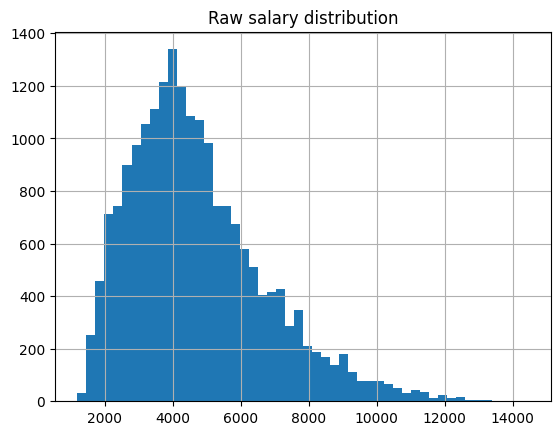

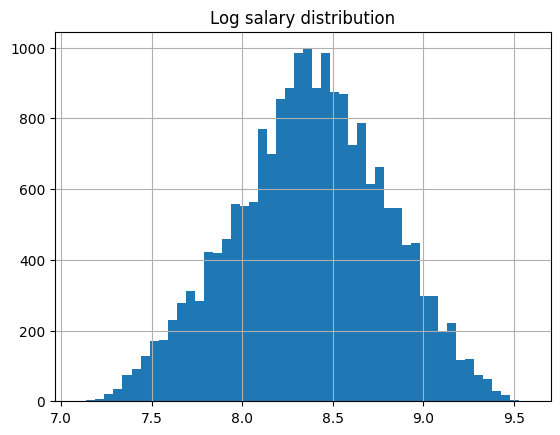

In [5]:
import matplotlib.pyplot as plt
import numpy as np

df["salary"].hist(bins=50)
plt.title("Raw salary distribution")
plt.show()

df["log_salary"] = np.log(df["salary"])

df["log_salary"].hist(bins=50)
plt.title("Log salary distribution")
plt.show()

Log transformation produces an approximately normal distribution, which justifies the ue of log-linear regression modeling.

## 5. Raw Salary Differences by Gender

We compute mean and median salaries by sex to assess any unadjusted pay disparities.

These comparisons do not control for rank, field, or experience and therefore do not imply discrimination.

In [6]:
df.groupby("sex")["salary"].agg(["count","mean","median"])

,count,mean,median
sex,,,
F,3926,4185.462274,3996.0
M,15866,4854.544617,4505.0


In [7]:
df.groupby("sex")["log_salary"].mean()

sex
F    8.273644
M    8.398635
Name: log_salary, dtype: float64

In [8]:
df = df.reset_index(drop=True)

## 6. Rank Composition by Gender

We examine the distribution of faculty ranks within each gender group.

This helps determine whether observed salary gaps are driven by rank composition rather than within-rank pay differences.

In [9]:
rank_dist = (
    df.groupby(["sex", "rank"])
      .size()
      .reset_index(name="count")
)

rank_dist["prop"] = (
    rank_dist["count"] /
    rank_dist.groupby("sex")["count"].transform("sum")
)

print(rank_dist)

  sex    rank  count      prop
0   F  Assist   1460  0.371880
1   F   Assoc   1465  0.373153
2   F    Full   1001  0.254967
3   M  Assist   2588  0.163157
4   M   Assoc   5064  0.319254
5   M    Full   8210  0.517589


In [10]:
pivot = rank_dist.pivot(index="rank", columns="sex", values="prop")
print(pivot)

sex            F         M
rank                      
Assist  0.371880  0.163157
Assoc   0.373153  0.319254
Full    0.254967  0.517589


Our above findings indicate that women are disproportionately represented in junior ranks, while men dominate Full Professor roles. This structural imbalance may explain much of the raw salary gap.

## 7. Within-Rank Salary Comparisons

To isolate pay differences conditional on rank, we compare average salaries within each academic rank.

This helps us separate structural inequality from direct pay discrimination.

In [11]:
df.groupby(["rank","sex"])["salary"].mean().unstack()

sex,F,M
rank,,
Assist,3390.336892,3387.458765
Assoc,4013.478557,3965.813033
Full,5596.890050,5865.128429


In [12]:
df.groupby(["rank","sex"])["log_salary"].mean().unstack()

sex,F,M
rank,,
Assist,8.072122,8.058546
Assoc,8.259003,8.224813
Full,8.589000,8.613006


Within-rank salary differences are relatively small. This suggests that overall wage disparities are driven more by rank distribution than pay inequity within rank.

In [13]:
import statsmodels.formula.api as smf

full_df = df[df["rank"] == "Full"]

model = smf.ols("log_salary ~ C(sex)", data=full_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.082
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0434
Time:                        14:47:39   Log-Likelihood:                -3527.2
No. Observations:                9211   AIC:                             7058.
Df Residuals:                    9209   BIC:                             7073.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.5890      0.011    765.678      

## 8. Career Stage Differences

We compare tenure and experience across genders to assess whether career timing contributes to rank and salary disparities.

In [14]:
df.groupby("sex")["tenure"].mean()

sex
F     8.124300
M    12.160847
Name: tenure, dtype: float64

In [15]:
df.groupby("sex")["experience"].mean()

sex
F    11.931737
M    16.165385
Name: experience, dtype: float64

Men exhibit substantially longer tenure and experience on average, which may contribute to higher promotion rates and salaries.

# Q1 - Starting Salary Discrimination
Do men and women start at different salaries when hired?

We isolate starting salaries by selecting observations where the observation year equals the hire year.

In [16]:
start_df = df[df["year"] == df["startyr"]].copy()
start_df.groupby("sex")["salary"].agg(["count","mean","median"])

,count,mean,median
sex,,,
F,354,3600.322901,3502.5
M,753,4015.545388,3719.0


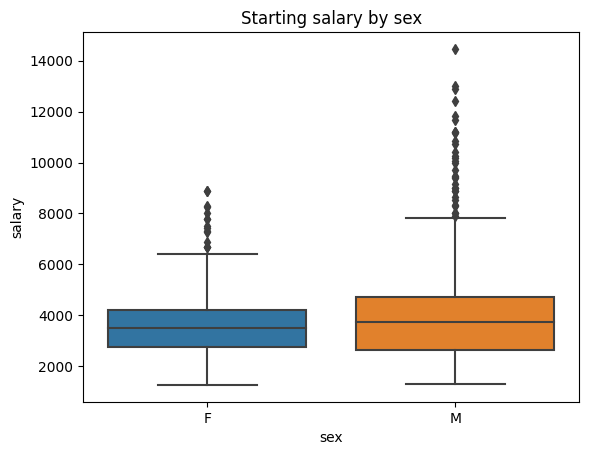

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=start_df, x="sex", y="salary")
plt.title("Starting salary by sex")
plt.show()

In the above boxplot and using the raw values before this, we notice that men start ~$415 higher on average. But descriptive does not equal discrimination.
We must adjust for covariates.

We estimate a log-linear regression model predicting starting salary as a function of:

- Gender
- Academic field
- Degree type
- Prior experience


In [18]:
import statsmodels.formula.api as smf

model_q1 = smf.ols(
    "np.log(salary) ~ C(sex) + C(field) + C(deg) + experience",
    data=start_df
).fit()

print(model_q1.summary())

                            OLS Regression Results                            
Dep. Variable:         np.log(salary)   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     61.93
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           3.00e-66
Time:                        14:47:40   Log-Likelihood:                -471.98
No. Observations:                1107   AIC:                             958.0
Df Residuals:                    1100   BIC:                             993.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.7255      0.04

The gender coefficient is not statistically significant (p = 0.174), which means there is no evidence of systematic starting salary discrimination after controlling for the relevant covariates.

Field, degree, and experience are significant predictors of starting salary, suggesting that observed raw gaps are explained by structural differences rather than discriminatory pay-setting.

Q2

In [19]:

assoc_df = df[df["rank"] == "Assoc"].copy()


promotion_status = (
    df.groupby("id")["rank"]
      .apply(lambda x: (x == "Full").any())
      .reset_index(name="ever_full")
)


assoc_summary = (
    assoc_df.groupby("id")
    .agg(
        sex=("sex","first"),
        assoc_years=("tenure","count"),
        max_tenure=("tenure","max")
    )
    .reset_index()
)


promotion = assoc_summary.merge(promotion_status, on="id")

print(promotion.head())

   id sex  assoc_years  max_tenure  ever_full
0   7   M           17          24      False
1   9   M            6           8      False
2  10   M           13          12       True
3  13   M            6          12       True
4  14   M            2           1       True


In [20]:
promotion.groupby("sex")["ever_full"].mean()

sex
F    0.420168
M    0.599196
Name: ever_full, dtype: float64

In [21]:
print(promotion["ever_full"].dtype)
print(promotion["ever_full"].unique())

bool
[False  True]


In [22]:
promotion["ever_full"] = promotion["ever_full"].astype(int)

In [23]:
import statsmodels.formula.api as smf

model_q2 = smf.logit(
    "ever_full ~ C(sex) + max_tenure",
    data=promotion
).fit()

print(model_q2.summary())

Optimization terminated successfully.
         Current function value: 0.654339
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              ever_full   No. Observations:                  984
Model:                          Logit   Df Residuals:                      981
Method:                           MLE   Df Model:                            2
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                 0.04738
Time:                        14:47:41   Log-Likelihood:                -643.87
converged:                       True   LL-Null:                       -675.90
Covariance Type:            nonrobust   LLR p-value:                 1.234e-14
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3430      0.170      2.018      0.044       0.010       0.676
C(sex)[T.M]     0.7804    

In [24]:
promotion.groupby("sex").agg(
    promotion_rate=("ever_full","mean"),
    avg_tenure=("max_tenure","mean"),
    count=("id","count")
)

,promotion_rate,avg_tenure,count
sex,,,
F,0.420168,10.205882,238
M,0.599196,10.682306,746


Q3

In [25]:
model_3 = smf.ols(
    "log_salary ~ C(sex) + experience + C(rank) + admin",
    data=df
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     2484.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:47:41   Log-Likelihood:                -6042.6
No. Observations:               19788   AIC:                         1.210e+04
Df Residuals:                   19782   BIC:                         1.214e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.9688      0.007  